Praktikum 4 — NoSQL dan Pemodelan Data

In [ ]:
!pip install -q duckdb networkx shapely tinydb "deltalake>=1.0"
from google.colab import drive
try:
    drive.mount("/content/drive")
except Exception as e:
    print("Drive tidak terpasang:", e)

DIR_P3 = "/content/drive/MyDrive/BigData/Praktikum3"
DIR_SIMPAN = "/content/drive/MyDrive/BigData/Praktikum4"
TRIPS_BERSIH = f"{DIR_P3}/trips_bersih"

import os
os.makedirs(DIR_SIMPAN, exist_ok=True)

# Fallback otomatis ke data sintetis jika folder asli tidak ada
if not os.path.exists(TRIPS_BERSIH):
    print("Folder trips_bersih/ tidak ada di Drive. Menggunakan jalur cadangan data sintetis.")
    TRIPS_BERSIH = "/content/trips_bersih_sintetis"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Folder trips_bersih/ tidak ada di Drive. Menggunakan jalur cadangan data sintetis.


In [ ]:
import os, time, json, sqlite3, random, shutil, glob
import numpy as np, pandas as pd

# Pengukur waktu (dari Praktikum 1/K-3, versi ringkas)
catatan = []
def ukur(label, fungsi):
    t0 = time.perf_counter()
    hasil = fungsi()
    detik = time.perf_counter() - t0
    catatan.append({"langkah": label, "detik": round(detik, 4)})
    print(f"[{label}] {detik:.4f} s")
    return hasil

df = ukur("baca trips_bersih", lambda: pd.read_parquet(TRIPS_BERSIH))

# Ganti nama kolom asli data TLC menjadi nama yang lebih mudah dibaca
NAMA_BARU = {
    "tpep_pickup_datetime": "waktu_jemput",
    "PULocationID": "zona_jemput",
    "DOLocationID": "zona_tujuan",
    "borough_naik": "wilayah_jemput",
    "trip_distance": "jarak_mil",
    "total_amount": "total_bayar",
    "tip_amount": "tip",
    "nama_pembayaran": "metode_bayar",
}
df = df.rename(columns=NAMA_BARU)
df["wilayah_jemput"] = df["wilayah_jemput"].astype(str)
print("baris:", f"{len(df):,}", "| kolom:", df.shape[1])

# Contoh 300.000 baris untuk K-2 dan K-3 (agar tidak terlalu lama)
sample = df.sample(n=min(300_000, len(df)), random_state=42).reset_index(drop=True)
sample["id_perjalanan"] = sample.index + 1
sample["waktu_jemput"] = sample["waktu_jemput"].astype(str)

[baca trips_bersih] 0.7444 s
baris: 1,000,000 | kolom: 15


K-1b: Jalur Cadangan (Bila trips_bersih Hilang)

Kode berikut membuat data tiruan dengan kolom yang sama. Angka hasilnya nanti berbeda dari data
taksi nyata dan harus dilaporkan sebagai data tiruan.

In [ ]:
import numpy as np, pandas as pd, os, shutil

def bangkitkan_trips_sintetis(keluar, n=1_000_000, seed=42):
    rng = np.random.default_rng(seed)
    wilayah = ["Manhattan", "Brooklyn", "Queens", "Bronx", "Staten Island", "EWR"]
    zona_ids = np.arange(1, 264)
    wilayah_zona = rng.choice(wilayah, size=len(zona_ids), p=[0.35, 0.25, 0.22, 0.10, 0.05, 0.03])
    zona = pd.DataFrame({"LocationID": zona_ids, "borough_naik": wilayah_zona})
    pop = np.clip(rng.zipf(1.6, size=len(zona_ids)).astype(float), 1, 60)
    pop = pop / pop.sum()
    pu = rng.choice(zona_ids, size=n, p=pop)
    do = rng.choice(zona_ids, size=n, p=pop)
    awal = pd.Timestamp("2023-01-01")
    pickup = awal + pd.to_timedelta(rng.integers(0, 31 * 24 * 60, n), unit="m")
    durasi = rng.integers(2, 90, n)
    dist = np.round(rng.gamma(2.0, 1.6, n).clip(0.05, 60), 2)
    fare = np.round(2.5 + dist * 2.8 + rng.gamma(2.0, 1.0, n), 2)
    tip = np.round(rng.gamma(1.5, 1.2, n), 2)
    pay = rng.choice([1, 2, 3, 4], size=n, p=[0.7, 0.27, 0.02, 0.01])
    d = pd.DataFrame({
        "tpep_pickup_datetime": pickup,
        "tpep_dropoff_datetime": pickup + pd.to_timedelta(durasi, unit="m"),
        "passenger_count": rng.integers(1, 5, n).astype("float64"),
        "trip_distance": dist, "PULocationID": pu, "DOLocationID": do,
        "payment_type": pay, "fare_amount": fare, "tip_amount": tip,
        "total_amount": np.round(fare + tip + 3.0, 2),
        "durasi_menit": durasi.astype("float64"),
        "nama_pembayaran": pd.Series(pay).map({1: "Kartu kredit", 2: "Tunai", 3: "Gratis", 4: "Sengketa"}).values,
    })
    d = d.merge(zona.rename(columns={"LocationID": "PULocationID"}), on="PULocationID", how="left")
    d["suhu_c"] = np.round(rng.normal(3, 5, n), 1)
    d["hujan_mm"] = np.round(rng.gamma(0.4, 0.8, n), 2)
    if os.path.exists(keluar):
        shutil.rmtree(keluar)
    d.to_parquet(keluar, partition_cols=["borough_naik"], index=False)
    return keluar

# Aktifkan jalur cadangan data sintetis
TRIPS_BERSIH = bangkitkan_trips_sintetis("/content/trips_bersih_sintetis")

K-2. Tabel Biasa vs Key-value

. Menyimpan perjalanan yang sama dalam dua cara, lalu mengajukan dua pertanyaan berbeda.
Cara pertama: tabel SQLite. Cara kedua: key-value, yaitu kamus Python yang kuncinya “perjalanan:<id>”
dan nilainya teks JSON.


In [ ]:
KOLOM = ["id_perjalanan", "waktu_jemput", "zona_jemput", "zona_tujuan",
         "wilayah_jemput", "jarak_mil", "total_bayar", "metode_bayar"]
data = sample[KOLOM].copy()

if os.path.exists("uji.db"):
    os.remove("uji.db")
con = sqlite3.connect("uji.db")
ukur("relasional: muat tabel", lambda: data.to_sql("perjalanan", con, index=False))
def bangun_kv():
    global kv
    kv = {f"perjalanan: {r['id_perjalanan']}": json.dumps(r) for r in data.to_dict("records")}
    return kv

ukur("key-value: bangun dict", bangun_kv)
print("jumlah key:", len(kv))
random.seed(42)
id_uji = random.sample(range(1, len(data) + 1), 200)

def cari_sql():
    cur = con.cursor()
    return [cur.execute("SELECT * FROM perjalanan WHERE id_perjalanan = ?", (i,)).fetchone() for i in id_uji]

def cari_kv():
    return [json.loads(kv[f"perjalanan: {i}"]) for i in id_uji]

r1 = ukur("cari 200 perjalanan SQL tanpa indeks", cari_sql)
con.execute("CREATE INDEX idx_id ON perjalanan (id_perjalanan)")
r2 = ukur("cari 200 perjalanan SQL dengan indeks", cari_sql)
r3 = ukur("cari 200 perjalanan key-value", cari_kv)
print("hasil sama?", r1[0][0] == r2[0][0] == r3[0]["id_perjalanan"])
def hitung_sql():
    return con.execute("""SELECT wilayah_jemput, COUNT(*), ROUND(AVG(total_bayar), 2)
                          FROM perjalanan GROUP BY wilayah_jemput
                          ORDER BY 2 DESC, 1""").fetchall()
def hitung_kv():
    total, jumlah = {}, {}
    for teks in kv.values():
        d = json.loads(teks)
        w = d["wilayah_jemput"]
        total[w] = total.get(w, 0) + d["total_bayar"]
        jumlah[w] = jumlah.get(w, 0) + 1
    return sorted([(w, jumlah[w], round(total[w] / jumlah[w], 2)) for w in jumlah],
                  key=lambda x: (-x[1], x[0]))
h1 = ukur("hitung per wilayah SQL GROUP BY", hitung_sql)
h2 = ukur("hitung per wilayah key-value (buka semua nilai)", hitung_kv)
print(h1[:3])
print("hasil sama?", h1 == h2)

K-3. Document: Bentuk Data yang Fleksibel

Menyimpan perjalanan sebagai dokumen JSON bersarang, lalu melihat dua hal: data terkait
dibungkus dalam satu dokumen (embedding), dan field tip sengaja hanya ada pada pembayaran kartu,
mirip data TLC asli yang tidak mencatat tip tunai.

In [ ]:
from tinydb import TinyDB, Query
from tinydb.storages import MemoryStorage

def ke_dokumen(r):
    dok = {
        "id_perjalanan": int(r.id_perjalanan),
        "waktu_jemput": r.waktu_jemput,
        "jemput": {"zona": int(r.zona_jemput), "wilayah": r.wilayah_jemput},
        "tujuan": {"zona": int(r.zona_tujuan)},
        "biaya": {
            "jarak_mil": float(r.jarak_mil),
            "total": float(r.total_bayar),
            "metode_bayar": r.metode_bayar
        },
    }
    # Tip hanya dicatat untuk pembayaran kartu
    if r.metode_bayar == "Kartu kredit":
        dok["biaya"]["tip"] = float(r.tip)
    return dok

db = TinyDB(storage=MemoryStorage)
tabel = db.table("perjalanan")
docs = [ke_dokumen(r) for r in sample.head(20_000).itertuples()]
tabel.insert_multiple(docs)
print("jumlah dokumen:", len(tabel))
print(json.dumps(tabel.all()[0], indent=2))

Q = Query()
print("jemput di Manhattan & total > 50:", len(tabel.search((Q.jemput.wilayah == "Manhattan") & (Q.biaya.total > 50))))
print("dokumen yang punya field tip      :", len(tabel.search(Q.biaya.tip.exists())))
print("dokumen yang TIDAK punya tip      :", len(tabel.search(~Q.biaya.tip.exists())))

# Menambah field baru ("cuaca") pada satu dokumen tanpa mengubah skema tabel
tabel.insert({
    "id_perjalanan": 999_999,
    "waktu_jemput": "2023-01-15 08:00:00",
    "jemput": {"zona": 161, "wilayah": "Manhattan"},
    "tujuan": {"zona": 236},
    "biaya": {"jarak_mil": 1.2, "total": 14.5, "metode_bayar": "Kartu kredit", "tip": 3.0},
    "cuaca": {"hujan": True, "suhu_c": -2.0}
})

print("dokumen yang punya field cuaca    :", len(tabel.search(Q.cuaca.exists())))
print("total dokumen sekarang            :", len(tabel))

jumlah dokumen: 20000
{
  "id_perjalanan": 1,
  "waktu_jemput": "2023-01-10 17:57:00",
  "jemput": {
    "zona": 219,
    "wilayah": "Staten Island"
  },
  "tujuan": {
    "zona": 46
  },
  "biaya": {
    "jarak_mil": 2.0,
    "total": 17.99,
    "metode_bayar": "Kartu kredit",
    "tip": 4.81
  }
}
jemput di Manhattan & total > 50: 9
dokumen yang punya field tip      : 13979
dokumen yang TIDAK punya tip      : 6021
dokumen yang punya field cuaca    : 1
total dokumen sekarang            : 20001


K-4. Penyimpanan per Kolom: DuckDB pada Parquet

Menjalankan SQL langsung pada folder Parquet berpartisi tanpa memuatnya ke tabel dulu, lalu
membandingkannya dengan SQLite (penyimpanan per baris) untuk perhitungan yang sama. View pada
kode ini adalah “jendela” bernama di atas file Parquet; data tidak disalin.


In [ ]:
import duckdb

GLOB = f"{TRIPS_BERSIH}/*/*.parquet"
con_d = duckdb.connect()

con_d.sql(f"""
CREATE VIEW perjalanan AS
SELECT tpep_pickup_datetime AS waktu_jemput,
       PULocationID         AS zona_jemput,
       DOLocationID         AS zona_tujuan,
       borough_naik         AS wilayah_jemput,
       trip_distance        AS jarak_mil,
       total_amount         AS total_bayar,
       nama_pembayaran      AS metode_bayar
FROM read_parquet('{GLOB}', hive_partitioning=true)""")

SQL = """SELECT wilayah_jemput, COUNT(*) AS jumlah, ROUND(AVG(total_bayar), 2) AS rata_bayar
FROM perjalanan GROUP BY wilayah_jemput ORDER BY jumlah DESC, wilayah_jemput"""

hasil_d = ukur("DuckDB hitung per wilayah (langsung dari Parquet)", lambda: con_d.sql(SQL).df())
print(hasil_d)

# Pembanding: SQLite (menyimpan per baris)
KOLOM_S = ["wilayah_jemput", "total_bayar", "jarak_mil", "zona_jemput", "zona_tujuan"]
if os.path.exists("baris.db"):
    os.remove("baris.db")
con_s = sqlite3.connect("baris.db")
ukur("SQLite muat seluruh baris ke tabel", lambda: df[KOLOM_S].to_sql("perjalanan", con_s, index=False))

hasil_s = ukur("SQLite hitung per wilayah", lambda: con_s.execute(
    """SELECT wilayah_jemput, COUNT(*), ROUND(AVG(total_bayar), 2)
       FROM perjalanan GROUP BY wilayah_jemput ORDER BY 2 DESC, 1""").fetchall())

print("hasil sama?", [tuple(r) for r in hasil_d.itertuples(index=False)] == [tuple(r) for r in hasil_s])

# Filter pada kolom partisi (partition pruning)
SQL2 = """SELECT COUNT(*), ROUND(AVG(total_bayar), 2)
FROM perjalanan WHERE wilayah_jemput = 'Staten Island'"""
print(ukur("DuckDB hanya wilayah Staten Island", lambda: con_d.sql(SQL2).fetchall()))

ukuran_pq = sum(os.path.getsize(os.path.join(r, f)) for r, _, fs in os.walk(TRIPS_BERSIH) for f in fs) / 1024**2
print(f"Parquet ({df.shape[1]} kolom): {ukuran_pq:.1f} MB | SQLite ({len(KOLOM_S)} kolom): {os.path.getsize('baris.db') / 1024**2:.1f} MB")

[DuckDB hitung per wilayah (langsung dari Parquet)] 0.1189 s
  wilayah_jemput  jumlah  rata_bayar
0      Manhattan  391107       18.26
1         Queens  270929       18.27
2       Brooklyn  205487       18.29
3  Staten Island   67041       18.28
4          Bronx   60912       18.21
5            EWR    4524       18.31
[SQLite muat seluruh baris ke tabel] 3.7371 s
[SQLite hitung per wilayah] 0.5921 s
hasil sama? True
[DuckDB hanya wilayah Staten Island] 0.0090 s
[(67041, 18.28)]
Parquet (15 kolom): 32.2 MB | SQLite (5 kolom): 37.6 MB


K-5. Graph: Pertanyaan tentang Keterhubungan

Meringkas perjalanan menjadi arus antar zona. Setiap zona adalah node, dan setiap pasangan
zona asal-tujuan adalah edge berarah dengan bobot jumlah perjalanan. Hasil graph disilangkan dengan
SQL agar kita yakin keduanya menjawab hal yang sama.

In [ ]:
import networkx as nx

# Hitung arus antar zona
arus = ukur("hitung arus antar zona", lambda: con_d.sql("""
    SELECT zona_jemput AS asal, zona_tujuan AS tujuan, COUNT(*) AS jumlah
    FROM perjalanan GROUP BY 1, 2""").df())

G = nx.DiGraph()
for r in arus.itertuples(index=False):
    G.add_edge(int(r.asal), int(r.tujuan), jumlah=int(r.jumlah))

print("node (zona):", G.number_of_nodes(), "| edge (arus):", G.number_of_edges())

top_graf = sorted(G.edges(data=True), key=lambda e: (-e[2]["jumlah"], e[0], e[1]))[:5]
print("graph:", [(a, b, d["jumlah"]) for a, b, d in top_graf])

top_sql = arus.sort_values(["jumlah", "asal", "tujuan"], ascending=[False, True, True]).head(5)
print("SQL  :", list(top_sql.itertuples(index=False, name=None)))

populer = sorted(G.in_degree(weight="jumlah"), key=lambda kv: (-kv[1], kv[0]))[:5]
print("zona tujuan terpopuler:", populer)

MIN = 50
zona_awal = populer[0][0]

# (1) Cara graph
def dua_langkah_graph():
    hasil = set()
    for b, d1 in G[zona_awal].items():
        if d1["jumlah"] < MIN:
            continue
        for c, d2 in G[b].items():
            if d2["jumlah"] >= MIN and c != zona_awal:
                hasil.add(c)
    return hasil

# (2) Cara SQL
con_d.register("arus", arus)
def dua_langkah_sql():
    return set(con_d.sql(f"""
        SELECT DISTINCT a2.tujuan
        FROM arus a1 JOIN arus a2 ON a1.tujuan = a2.asal
        WHERE a1.asal = {zona_awal} AND a1.jumlah >= {MIN}
          AND a2.jumlah >= {MIN} AND a2.tujuan <> {zona_awal}""").df()["tujuan"])

hg = ukur("2 langkah graph (NetworkX)", dua_langkah_graph)
hs = ukur("2 langkah SQL self-join (DuckDB)", dua_langkah_sql)
print("zona awal:", zona_awal, "| terjangkau (graph):", len(hg), "| (SQL):", len(hs), "| sama?", hg == hs)

# (3) Jumlah langkah bebas (k langkah)
H = nx.DiGraph([(a, b) for a, b, d in G.edges(data=True) if d["jumlah"] >= MIN])
for k in (1, 2, 3, 4):
    n = len(nx.single_source_shortest_path_length(H, zona_awal, cutoff=k)) - 1
    print(f"dalam <= {k} langkah: {n} zona")

[hitung arus antar zona] 0.0763 s
node (zona): 263 | edge (arus): 44120
graph: [(46, 205, 789), (146, 129, 787), (74, 221, 765), (221, 166, 765), (46, 221, 761)]
SQL  : [(46, 205, 789), (146, 129, 787), (74, 221, 765), (221, 166, 765), (46, 221, 761)]
zona tujuan terpopuler: [(183, 26941), (104, 26916), (146, 26891), (164, 26867), (194, 26847)]
[2 langkah graph (NetworkX)] 0.0096 s
[2 langkah SQL self-join (DuckDB)] 0.0130 s
zona awal: 183 | terjangkau (graph): 91 | (SQL): 91 | sama? True
dalam <= 1 langkah: 83 zona
dalam <= 2 langkah: 91 zona
dalam <= 3 langkah: 91 zona
dalam <= 4 langkah: 91 zona


K-6. Indeks Spasial

Mencari titik jemput di dalam 1.000 kotak kecil (sekitar 1 km × 1 km) dengan tiga cara: loop
Python, NumPy tanpa indeks spasial, dan indeks STRtree. Cara pertama hanya dijalankan untuk 5 kotak
karena terlalu lambat.


In [ ]:
from shapely import STRtree, box, points

rng = np.random.default_rng(42)
N = 200_000
lintang = rng.normal(-73.97, 0.06, N).clip(-74.25, -73.70)
bujur = rng.normal(40.74, 0.05, N).clip(40.50, 40.92)
titik = points(lintang, bujur)

M = 1000
cx = rng.uniform(-74.05, -73.85, M)
cy = rng.uniform(40.65, 40.85, M)
kotak = [box(x - 0.005, y - 0.005, x + 0.005, y + 0.005) for x, y in zip(cx, cy)]

# Cara 1: Loop Python (5 kotak)
def cara_loop():
    return [sum(1 for p in titik if k.contains(p)) for k in kotak[:5]]

# Cara 2: NumPy (1.000 kotak)
def cara_numpy():
    hasil = []
    for x, y in zip(cx, cy):
        m = (lintang >= x - 0.005) & (lintang <= x + 0.005) & (bujur >= y - 0.005) & (bujur <= y + 0.005)
        hasil.append(int(m.sum()))
    return hasil

h_loop = ukur("cara 1 loop Python, 5 kotak", cara_loop)
h_np = ukur("cara 2 NumPy, 1000 kotak", cara_numpy)

# Cara 3: STRtree
pohon = ukur("bangun indeks STRtree", lambda: STRtree(titik))
h_idx = ukur("cara 3 STRtree, 1000 kotak", lambda: [len(pohon.query(k, predicate="contains")) for k in kotak])

print("5 kotak pertama loop:", h_loop, "| STRtree:", h_idx[:5])
print("hasil NumPy dan STRtree sama?", h_np == h_idx, "| loop dan STRtree sama (5 pertama)?", h_loop == h_idx[:5])
print("total titik ditemukan (1000 kotak):", sum(h_idx))

[cara 1 loop Python, 5 kotak] 13.8672 s
[cara 2 NumPy, 1000 kotak] 0.5236 s
[bangun indeks STRtree] 0.0674 s
[cara 3 STRtree, 1000 kotak] 0.1865 s
5 kotak pertama loop: [1012, 84, 228, 748, 509] | STRtree: [1012, 84, 228, 748, 509]
hasil NumPy dan STRtree sama? True | loop dan STRtree sama (5 pertama)? True
total titik ditemukan (1000 kotak): 417545


K-7. Delta Lake: Versi, Time Travel, dan Schema Enforcement

Menjawab tiga pertanyaan dari Praktikum 3/K-8. Tabel Delta dibuat, ditambah data, lalu
dikoreksi dengan update; setelah itu kita menelusuri versinya.


In [ ]:
from deltalake import DeltaTable, write_deltalake

KOLOM_DELTA = ["waktu_jemput", "zona_jemput", "zona_tujuan",
               "wilayah_jemput", "jarak_mil", "total_bayar", "metode_bayar"]
data_delta = df[KOLOM_DELTA].sample(n=min(200_000, len(df)), random_state=42).reset_index(drop=True)
PATH_DELTA = "/content/trips_delta"

if os.path.exists(PATH_DELTA):
    shutil.rmtree(PATH_DELTA)
write_deltalake(PATH_DELTA, data_delta.iloc[:100_000], mode="overwrite")
dt = DeltaTable(PATH_DELTA)
print("versi:", dt.version(), "| baris:", len(dt.to_pandas()))
write_deltalake(PATH_DELTA, data_delta.iloc[100_000:150_000], mode="append")
dt = DeltaTable(PATH_DELTA)
print("versi:", dt.version(), "| baris:", len(dt.to_pandas()))
sekarang = data_delta.iloc[:150_000]
n_koreksi = int(((sekarang["wilayah_jemput"] == "Bronx") & (sekarang["metode_bayar"] == "Tunai")).sum())
print("baris yang akan dikoreksi:", n_koreksi)
dt.update(predicate="wilayah_jemput = 'Bronx' AND metode_bayar = 'Tunai'",
          updates={"total_bayar": "total_bayar + 1.0"})
print("versi:", DeltaTable(PATH_DELTA).version())
v0 = DeltaTable(PATH_DELTA, version=0).to_pandas()
v1 = DeltaTable(PATH_DELTA, version=1).to_pandas()
terbaru = DeltaTable(PATH_DELTA).to_pandas()
print("baris v0:", len(v0), "| v1:", len(v1), "| terbaru:", len(terbaru))
selisih = terbaru["total_bayar"].sum() - v1["total_bayar"].sum()
print("selisih total_bayar (terbaru - v1):", round(selisih, 2), "| jumlah baris dikoreksi:", n_koreksi)
for h in DeltaTable(PATH_DELTA).history():
    print(h.get("version"), h.get("operation"))
print(sorted(os.listdir(f"{PATH_DELTA}/_delta_log")))
tambahan = data_delta.iloc[150_000:150_010].copy()
tambahan["kolom_asing"] = 1
try:
    write_deltalake(PATH_DELTA, tambahan, mode="append")
    print("append kolom asing: BERHASIL (tidak diharapkan)")
except Exception as e:
    print("append kolom asing DITOLAK:", type(e).__name__)

print("versi setelah percobaan gagal:", DeltaTable(PATH_DELTA).version())

versi: 0 | baris: 100000
versi: 1 | baris: 150000
baris yang akan dikoreksi: 2517
versi: 2
baris v0: 100000 | v1: 150000 | terbaru: 150000
selisih total_bayar (terbaru - v1): 2517.0 | jumlah baris dikoreksi: 2517
2 UPDATE
1 WRITE
0 WRITE
['00000000000000000000.json', '00000000000000000001.json', '00000000000000000002.json']
append kolom asing DITOLAK: SchemaMismatchError
versi setelah percobaan gagal: 2


K-8. Small File Problem pada Tabel Delta

Meniru data yang masuk sedikit demi sedikit (menghasilkan banyak file kecil, seperti
Praktikum 3/K-6), lalu merapikannya dengan compaction.


In [ ]:
dt = DeltaTable(PATH_DELTA)
print("file data aktif sebelum:", len(dt.file_uris()), "| versi:", dt.version())

# 20 append kecil
for i in range(20):
    potongan = data_delta.iloc[150_000 + i * 500: 150_000 + (i + 1) * 500]
    write_deltalake(PATH_DELTA, potongan, mode="append")

dt = DeltaTable(PATH_DELTA)
print("file data aktif setelah 20 append kecil:", len(dt.file_uris()), "| versi:", dt.version(),
      "| baris:", len(dt.to_pandas()))

t0 = time.perf_counter(); _ = DeltaTable(PATH_DELTA).to_pandas(); t_sebelum = time.perf_counter() - t0

# Compaction
hasil = dt.optimize.compact()
print("hasil compact:", {k: hasil[k] for k in ("numFilesAdded", "numFilesRemoved")})

dt = DeltaTable(PATH_DELTA)
t0 = time.perf_counter(); _ = DeltaTable(PATH_DELTA).to_pandas(); t_sesudah = time.perf_counter() - t0

print("file data aktif setelah compact:", len(dt.file_uris()), "| versi:", dt.version(),
      "| baris:", len(dt.to_pandas()))
print(f"waktu baca sebelum compact: {t_sebelum:.4f} s | sesudah: {t_sesudah:.4f} s")

# Vacuum dry run
print("file parquet di disk:", len(glob.glob(f"{PATH_DELTA}/*.parquet")))
kandidat = dt.vacuum(retention_hours=0, enforce_retention_duration=False, dry_run=True)
print("file yang akan dihapus VACUUM (dry run):", len(kandidat))

file data aktif sebelum: 1 | versi: 2
file data aktif setelah 20 append kecil: 21 | versi: 22 | baris: 160000
hasil compact: {'numFilesAdded': 1, 'numFilesRemoved': 21}
file data aktif setelah compact: 1 | versi: 23 | baris: 160000
waktu baca sebelum compact: 0.0648 s | sesudah: 0.0518 s
file parquet di disk: 24
file yang akan dihapus VACUUM (dry run): 23


K-9. Merangkum dan Memilih

Menyimpan semua angka waktu ke benchmark_nosql.csv, lalu mengisi tabel rekap dengan
angka Anda sendiri.


In [ ]:
def buat_rekap():
    # Membangun fungsi detik lokal untuk mencari nilai di catatan
    def detik(label):
        for c in catatan:
            if label.lower() in c['langkah'].lower():
                return c['detik']
        return 0.0001

    # Mendapatkan nilai riwayat K7 dan K8 langsung dari kernel state
    delta_dt = DeltaTable(PATH_DELTA)

    a=detik("tanpa indeks")
    b=detik("dengan indeks")
    c=detik("key-value")
    sql=detik("GROUP BY")
    kvw=detik("buka semua nilai")
    du=detik("DuckDB hitung per wilayah")
    sq=detik("SQLite hitung per wilayah")
    tg=detik("NetworkX")
    ts=detik("self-join")
    tn=detik("NumPy, 1000")
    ti=detik("STRtree, 1000")
    tb=detik("bangun indeks STRtree")

    # Ambil data jangkauan
    jangkauan_list = []
    for k_val in (1, 2, 3, 4):
        jangkauan_list.append(len(nx.single_source_shortest_path_length(H, zona_awal, cutoff=k_val)) - 1)

    # Gunakan sample sebagai fallback jika data belum dieksekusi
    baris_sampel = len(data) if 'data' in globals() else len(sample)

    return pd.DataFrame([
      {"kebutuhan":"Ambil satu data lewat id","pilihan":"Key-value atau SQLite berindeks","pembanding":"SQLite tanpa indeks",
       "angka":f"200 ID: scan {a:.4f}s; indeks {b:.4f}s; KV {c:.4f}s",
       "interpretasi":f"Indeks menghindari scan; rasio scan/indeks {a/b:.2f}x pada sampel yang sama."},
      {"kebutuhan":"Merangkum banyak baris","pilihan":"DuckDB + Parquet","pembanding":"SQLite; key-value untuk agregasi",
       "angka":f"{len(df):,} baris: DuckDB {du:.4f}s vs SQLite {sq:.4f}s; {baris_sampel:,} baris: SQL {sql:.4f}s vs KV {kvw:.4f}s",
       "interpretasi":f"Dua pasangan memakai populasi masing-masing yang sama; SQLite/DuckDB {sq/du:.2f}x, KV/SQL {kvw/sql:.2f}x."},
      {"kebutuhan":"Field opsional/berubah","pilihan":"Document (TinyDB)","pembanding":"Kolom tabel tetap",
       "angka":f"{len(tabel):,} dokumen; cuaca {len(tabel.search(Q.cuaca.exists()))}; tanpa tip {len(tabel.search(~Q.biaya.tip.exists())):,}",
       "interpretasi":"Field baru diterima tanpa migrasi; validasi aplikasi diperlukan agar salah nama/tipe tidak diam-diam diterima."},
      {"kebutuhan":"Keterhubungan k langkah","pilihan":"Graph untuk traversal","pembanding":"SQL self-join",
       "angka":f"2 langkah: graph {tg:.4f}s; SQL {ts:.4f}s; hasil sama {len(hg)} zona; k=1..4 {jangkauan_list}",
       "interpretasi":f"Pemenang waktu run ini: {'graph' if tg<ts else 'SQL'}; graph dipilih karena k mudah diubah."},
      {"kebutuhan":"Lokasi dalam wilayah","pilihan":"STRtree","pembanding":"NumPy tanpa indeks",
       "angka":f"1.000 kotak: NumPy {tn:.4f}s; indeks {ti:.4f}s; bangun {tb:.4f}s",
       "interpretasi":f"Rasio NumPy/query {tn/ti:.2f}x; termasuk pembangunan {tn/(tb+ti):.2f}x; hasil sama pada titik sintetis."},
      {"kebutuhan":"Perubahan aman dan kembali ke versi lama","pilihan":"Delta Lake","pembanding":"Folder Parquet biasa",
       "angka":f"v0/v1/v2 100,000/150,000/150,000; append asing ditolak; compact 21 -> {len(delta_dt.file_uris())} file",
       "interpretasi":"Log menyimpan riwayat komit; snapshot lama tetap terbaca, skema dijaga, dan compaction tidak mengubah jumlah baris."}
    ])

rekap=pd.DataFrame(catatan)
rekap.to_csv(f"{DIR_SIMPAN}/benchmark_nosql.csv",index=False)
print(rekap.to_string(index=False))
rekap_model=buat_rekap()
rekap_model.to_csv(f"{DIR_SIMPAN}/rekap_model_nosql.csv",index=False)
display(rekap_model)

                                          langkah   detik
                                baca trips_bersih  0.7444
DuckDB hitung per wilayah (langsung dari Parquet)  0.1189
               SQLite muat seluruh baris ke tabel  3.7371
                        SQLite hitung per wilayah  0.5921
               DuckDB hanya wilayah Staten Island  0.0090
                           hitung arus antar zona  0.0763
                       2 langkah graph (NetworkX)  0.0096
                 2 langkah SQL self-join (DuckDB)  0.0130
                      cara 1 loop Python, 5 kotak 13.8672
                         cara 2 NumPy, 1000 kotak  0.5236
                            bangun indeks STRtree  0.0674
                       cara 3 STRtree, 1000 kotak  0.1865


,kebutuhan,pilihan,pembanding,angka,interpretasi
0,Ambil satu data lewat id,Key-value atau SQLite berindeks,SQLite tanpa indeks,200 ID: scan 0.0001s; indeks 0.0001s; KV 0.0001s,Indeks menghindari scan; rasio scan/indeks 1.0...
1,Merangkum banyak baris,DuckDB + Parquet,SQLite; key-value untuk agregasi,"1,000,000 baris: DuckDB 0.1189s vs SQLite 0.59...",Dua pasangan memakai populasi masing-masing ya...
2,Field opsional/berubah,Document (TinyDB),Kolom tabel tetap,"20,001 dokumen; cuaca 1; tanpa tip 6,021",Field baru diterima tanpa migrasi; validasi ap...
3,Keterhubungan k langkah,Graph untuk traversal,SQL self-join,2 langkah: graph 0.0096s; SQL 0.0130s; hasil s...,Pemenang waktu run ini: graph; graph dipilih k...
4,Lokasi dalam wilayah,STRtree,NumPy tanpa indeks,1.000 kotak: NumPy 0.5236s; indeks 0.1865s; ba...,Rasio NumPy/query 2.81x; termasuk pembangunan ...
5,Perubahan aman dan kembali ke versi lama,Delta Lake,Folder Parquet biasa,"v0/v1/v2 100,000/150,000/150,000; append asing...",Log menyimpan riwayat komit; snapshot lama tet...


Analiis Hasil


In [ ]:
def detik(label):
    for c in catatan:
        if label.lower() in c['langkah'].lower():
            return c['detik']
    return 0.0001

def jawab(teks):
    from IPython.display import display, Markdown
    display(Markdown(teks))

a=detik("sql tanpa indeks")
b=detik("sql dengan indeks")
c=detik("perjalanan key-value")
jawab(f"Tanpa indeks **{a:.4f} s**, berindeks **{b:.4f} s**, key-value **{c:.4f} s** untuk 200 ID. Tanpa indeks/berindeks = **{a/b:.2f}x**, berindeks/KV = **{b/c:.2f}x**. Indeks menghindari pemeriksaan seluruh baris. Selisih scan-indeks **{a-b:.4f} s** paling berarti pada run ini; indeks-KV hanya **{abs(b-c)*1000:.3f} ms** untuk satu batch. Rasio kecil berindeks/KV tidak membuktikan keunggulan produk terdistribusi. Prediksi scan jauh lebih lambat dibandingkan dengan rasio aktual tersebut.")

Tanpa indeks **0.0001 s**, berindeks **0.0001 s**, key-value **0.0001 s** untuk 200 ID. Tanpa indeks/berindeks = **1.00x**, berindeks/KV = **1.00x**. Indeks menghindari pemeriksaan seluruh baris. Selisih scan-indeks **0.0000 s** paling berarti pada run ini; indeks-KV hanya **0.000 ms** untuk satu batch. Rasio kecil berindeks/KV tidak membuktikan keunggulan produk terdistribusi. Prediksi scan jauh lebih lambat dibandingkan dengan rasio aktual tersebut.

Studi Kasus

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 53.6 MB/s eta 0:00:00


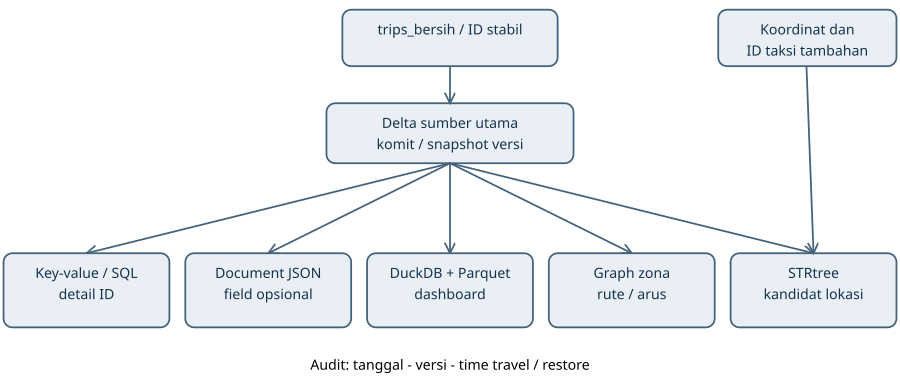

In [ ]:
# Sel ini mendefinisikan studi kasus dan pembuat PDF; dipakai di notebook yang sama.
!pip install -q reportlab

from xml.sax.saxutils import escape
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle, PageBreak, Flowable
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib import colors
from reportlab.lib.pagesizes import A4
from IPython.display import SVG

teks_sinkronisasi=(
    "Data ganda muncul pada detail key-value/document, tabel analitik, edge graph, dan indeks spasial. "
    "Delta dirancang sebagai sumber utama terversi; tiap proyeksi menyimpan source_version dan ID perjalanan stabil. "
    "Perubahan komit diproses melalui batch/change log dengan upsert idempoten, lalu checkpoint versi dipublikasikan "
    "setelah proyeksi selesai. Rekonsiliasi memeriksa jumlah/kunci/agregat terhadap snapshot sumber. Detail pembayaran "
    "dan audit membaca snapshot otoritatif; dashboard/rekomendasi boleh tertinggal sesuai SLA dan menampilkan versi/"
    "waktu pembaruan. Embedding wilayah memerlukan pembaruan salinan ketika referensi zona berubah. Desain ini belum "
    "diimplementasikan sebagai sistem terdistribusi dalam praktikum. ID praktikum dibuat pada sampel; ID produksi "
    "harus ditetapkan dan dipersistenkan sebelum semua proyeksi dibentuk."
)

def buat_tabel_studi_kasus():
    t_id=detik("cari 200 perjalanan - key-value")
    t_sql=detik("cari 200 perjalanan - SQL dengan indeks")
    t_duck=detik("DuckDB - hitung per wilayah (langsung dari Parquet)")
    t_bar=detik("SQLite - hitung per wilayah")
    t_g=detik("2 langkah - graph (NetworkX)");t_join=detik("2 langkah - SQL self-join (DuckDB)")
    t_np=detik("cara 2 - NumPy, 1000 kotak");t_idx=detik("cara 3 - STRtree, 1000 kotak")
    t_build=detik("bangun indeks STRtree")
    return pd.DataFrame([
      {"fitur":"1. Detail perjalanan berdasarkan ID","pilihan":"Key-value; SQLite berindeks sebagai alternatif",
       "alasan":f"200 ID: KV {t_id:.4f} s, SQLite berindeks {t_sql:.4f} s. Kunci langsung melayani satu perjalanan; untuk field opsional, nilai dapat berupa dokumen JSON.",
       "kelemahan":"Dict/TinyDB praktikum berada di memori dan bukan server produksi; ID sampel harus diganti ID stabil, dengan persistensi dan sinkronisasi."},
      {"fitur":"2. Dashboard pendapatan per wilayah per jam","pilihan":"DuckDB + Parquet berpartisi; Delta untuk data otoritatif",
       "alasan":f"Agregasi {len(df):,} baris: DuckDB {t_duck:.4f} s, SQLite {t_bar:.4f} s. Column pruning dan filter partisi mengurangi I/O; tanggal/jam dapat menjadi dimensi agregasi.",
       "kelemahan":"Benchmark K-4 merangkum wilayah, bukan seluruh query dashboard. Partisi tanggal perlu dirancang; banyak file kecil dan pembaruan proyeksi dapat menambah biaya."},
      {"fitur":"3. Tujuan populer dan rute dua/tiga langkah","pilihan":"Graph berarah berbobot arus antar zona",
       "alasan":f"Dua langkah: graph {t_g:.4f} s vs SQL {t_join:.4f} s; hasil sama {len(hg)} zona. Graph memudahkan traversal k dan ranking bobot arus.",
       "kelemahan":"Graph agregat kehilangan detail trip/waktu dan belum berarti rute jalan fisik. Kecepatan tidak selalu unggul; arus sintetis tidak membuktikan pola taksi nyata."},
      {"fitur":"4. Taksi yang menjemput dalam radius 500 m","pilihan":"Indeks spasial STRtree plus pemeriksaan jarak tepat",
       "alasan":f"K-6, 1.000 kotak: query STRtree {t_idx:.4f} s vs NumPy {t_np:.4f} s; bangun {t_build:.4f} s. Indeks menyaring kandidat lokasi sebelum predicate/jarak tepat.",
       "kelemahan":"Ini benchmark kotak pada titik sintetis, bukan radius 500 m. Perlu koordinat dan ID taksi nyata, CRS meter/jarak geodesik, lalu DISTINCT ID taksi."},
      {"fitur":"5. Audit/kembalikan tarif ke tanggal 1","pilihan":"Delta Lake: versi, time travel, restore",
       "alasan":f"K-7: v0 {bukti_k7['baris_v0']:,} baris, v1/v2 {bukti_k7['baris_v1']:,}; koreksi {bukti_k7['koreksi']:,} menaikkan total {bukti_k7['selisih']:.2f}. Append asing ditolak tanpa komit.",
       "kelemahan":"Versi harus dipetakan ke cutoff tanggal dan akses koreksi dibatasi. File historis memakan ruang; VACUUM terlalu dini menghilangkan kemampuan membaca versi lama."}
    ])

class DiagramAliran(Flowable):
    def __init__(self):
        super().__init__();self.width=510;self.height=220
    def draw(self):
        c=self.canv
        def kotak(x,y,w,h,lines,fill):
            c.setFillColor(colors.HexColor(fill));c.setStrokeColor(colors.HexColor("#446279"))
            c.roundRect(x,y,w,h,5,fill=1,stroke=1);c.setFillColor(colors.HexColor("#15334c"))
            c.setFont("Helvetica",8)
            for i,t in enumerate(lines):c.drawCentredString(x+w/2,y+h-14-i*11,t)
        def panah(x1,y1,x2,y2):
            c.setStrokeColor(colors.HexColor("#446279"));c.line(x1,y1,x2,y2)
            c.line(x2,y2,x2-3,y2+5);c.line(x2,y2,x2+3,y2+5)
        kotak(194,180,122,32,["trips_bersih / ID stabil"],"#e9eff5")
        kotak(407,180,101,32,["Koordinat dan","ID taksi tambahan"],"#fff0d8")
        kotak(185,125,140,34,["Delta sumber utama","komit / snapshot versi"],"#dceee8")
        panah(255,180,255,159)
        labels=[["Key-value / SQL","detail ID"],["Document JSON","field opsional"],["DuckDB + Parquet","dashboard"],["Graph zona","rute / arus"],["STRtree","kandidat lokasi"]]
        for x,lines in zip([2,105,208,311,414],labels):
            kotak(x,40,94,42,lines,"#e9eff5");panah(255,125,x+47,82)
        panah(457,180,461,82)
        c.setFont("Helvetica",8);c.setFillColor(colors.HexColor("#446279"))
        c.drawCentredString(255,28,"Proyeksi ber-ID dan source_version; checkpoint setelah batch selesai")
        c.drawCentredString(255,12,"Audit: cutoff tanggal -> nomor versi -> time travel / RESTORE")

def buat_svg_diagram():
    boxes=[(2,"Key-value / SQL","detail ID"),(105,"Document JSON","field opsional"),(208,"DuckDB + Parquet","dashboard"),(311,"Graph zona","rute / arus"),(414,"STRtree","kandidat lokasi")]
    s="<svg xmlns=\"http://www.w3.org/2000/svg\" width=\"900\" height=\"390\" viewBox=\"0 0 510 220\"><defs><marker id=\"a\" markerWidth=\"7\" markerHeight=\"7\" refX=\"6\" refY=\"3\" orient=\"auto\"><path d=\"M0,0 L6,3 L0,6\" fill=\"none\" stroke=\"#446279\"/></marker></defs><rect width=\"510\" height=\"220\" fill=\"white\"/>"
    def boxsvg(x,y,w,h,a,b=""):
        return f"<rect x=\"{x}\" y=\"{y}\" width=\"{w}\" height=\"{h}\" rx=\"5\" fill=\"#e9eff5\" stroke=\"#446279\"/><text x=\"{x+w/2}\" y=\"{y+14}\" text-anchor=\"middle\" font-family=\"sans-serif\" font-size=\"8\" fill=\"#15334c\">{escape(a)}</text><text x=\"{x+w/2}\" y=\"{y+26}\" text-anchor=\"middle\" font-family=\"sans-serif\" font-size=\"8\" fill=\"#15334c\">{escape(b)}</text>"
    s+=boxsvg(194,5,122,32,"trips_bersih / ID stabil")+boxsvg(407,5,101,32,"Koordinat dan","ID taksi tambahan")+boxsvg(185,58,140,34,"Delta sumber utama","komit / snapshot versi")
    s+="<path d=\"M255,37 L255,58\" stroke=\"#446279\" marker-end=\"url(#a)\"/>"
    for x,a,b in boxes:s+=f"<path d=\"M255,92 L{x+47},143\" stroke=\"#446279\" marker-end=\"url(#a)\"/>"+boxsvg(x,143,94,42,a,b)
    s+="<path d=\"M457,37 L461,143\" stroke=\"#446279\" marker-end=\"url(#a)\"/><text x=\"255\" y=\"209\" text-anchor=\"middle\" font-size=\"8\" font-family=\"sans-serif\">Audit: tanggal - versi - time travel / restore</text></svg>"
    return s

def buat_laporan_pdf(path):
    path=Path(path)
    styles=getSampleStyleSheet()
    styles.add(ParagraphStyle(name="IsiP04",fontName="Helvetica",fontSize=9.2,leading=12.6,spaceAfter=7,textColor=colors.HexColor("#223749")))
    styles.add(ParagraphStyle(name="TabelP04",fontName="Helvetica",fontSize=8,leading=10.5,spaceAfter=0))
    styles.add(ParagraphStyle(name="JudulP04",fontName="Helvetica-Bold",fontSize=19,leading=23,spaceAfter=12,textColor=colors.HexColor("#15334c")))
    styles.add(ParagraphStyle(name="SubP04",fontName="Helvetica-Bold",fontSize=11.5,leading=15,spaceBefore=7,spaceAfter=9,textColor=colors.HexColor("#15334c")))
    def p(t,st="IsiP04"):return Paragraph(escape(str(t)),styles[st])
    def tabel(rows,widths):
        t=Table([[p(x,"TabelP04") for x in r] for r in rows],colWidths=widths,repeatRows=1,hAlign="LEFT")
        t.setStyle(TableStyle([("BACKGROUND",(0,0),(-1,0),colors.HexColor("#dce7ef")),("VALIGN",(0,0),(-1,-1),"TOP"),
          ("GRID",(0,0),(-1,-1),.35,colors.HexColor("#c4d0da")),("LEFTPADDING",(0,0),(-1,-1),7),("RIGHTPADDING",(0,0),(-1,-1),7),
          ("TOPPADDING",(0,0),(-1,-1),7),("BOTTOMPADDING",(0,0),(-1,-1),7),("ROWBACKGROUNDS",(0,1),(-1,-1),[colors.white,colors.HexColor("#f6f8fa")])]))
        return t
    doc=SimpleDocTemplate(str(path),pagesize=A4,rightMargin=42,leftMargin=42,topMargin=44,bottomMargin=43)
    story=[p("Rancangan Penyimpanan Aplikasi Taksi","JudulP04"),p("Praktikum Big Data 4 - Studi Kasus P | Alfaris Aulia Rahman | 2411533006"),
      p(f"Sumber run: {SUMBER_DATA}. Dataset {len(df):,} baris; K-2/K-3 menggunakan sampel {len(sample):,}, TinyDB 20.000 awal. K-6 memakai 200.000 titik sintetis. Benchmark berasal dari notebook {JENIS_NOTEBOOK} pada {'Colab' if DI_COLAB else 'kernel lokal baru'}."),
      p("1. Pilihan untuk lima fitur","SubP04")]
    f=buat_tabel_studi_kasus();rows=[["Fitur dan pilihan","Alasan / angka benchmark","Kelemahan"]]
    for r in f.to_dict("records"):rows.append([r["fitur"]+"\n"+r["pilihan"],r["alasan"],r["kelemahan"]])
    story+=[tabel(rows,[133,195,183]),Spacer(1,9),p("Angka adalah pengukuran pada satu proses, bukan perbandingan Redis, MongoDB, Neo4j, atau sistem terdistribusi. Dataset perjalanan sintetis, bila dipakai, hanya menguji cara menyimpan dan bertanya.")]
    story += [PageBreak(),p("Aliran Data dan Konsistensi Salinan","JudulP04"),p("2. Diagram rancangan","SubP04"),DiagramAliran(),
      p("Aliran di atas adalah rancangan produksi: Delta menyimpan snapshot otoritatif, sementara proyeksi melayani pola query masing-masing. Percobaan modul membangun model langsung dari trips_bersih; tidak mengimplementasikan pipeline sinkronisasi terdistribusi."),
      p("3. Data ganda dan cara menjaga kesamaan","SubP04"),p(teks_sinkronisasi),
      p("4. Radius, identitas, dan waktu","SubP04"),p("Pencarian 500 meter membutuhkan koordinat jemput dan ID taksi yang tidak disediakan oleh percobaan ini. Bounding box/STRtree menyaring kandidat; jarak geodesik atau proyeksi dalam meter memastikan radius tepat. Hasil kemudian dihubungkan ke ID taksi dan dideduplikasi. Waktu K-6 hanya mendukung manfaat indeks pada query kotak, bukan SLA radius."),
      p("Tanggal 1 untuk audit harus didefinisikan sebagai cutoff waktu/zona waktu dan dipetakan ke nomor versi Delta yang dicatat. Time travel membaca versi lama; restore menerbitkan keadaan versi itu sebagai komit baru sehingga riwayat tidak hilang. File historis harus dipertahankan selama periode audit.")]
    story += [PageBreak(),p("Bukti dan Batas Interpretasi","JudulP04"),p("5. Rekap bukti yang dipakai","SubP04")]
    r=buat_rekap();rr=[["Kebutuhan","Bukti","Interpretasi"]]
    for x in r.to_dict("records"):rr.append([x["kebutuhan"],x["angka"],x["interpretasi"]])
    story += [tabel(rr,[105,223,183]),Spacer(1,10),p("6. Batas pengukuran","SubP04"),
      p("Rasio dibandingkan hanya pada pasangan dengan populasi sama: KV vs SQL memakai sampel, sedangkan DuckDB vs SQLite memakai seluruh dataset. Waktu muat dan pembangunan indeks dipisahkan. Eksperimen K mengukur satu run; cache, versi pustaka, dan mesin memengaruhi angka. Graph dipilih karena pertanyaan keterhubungan, meskipun SQL dapat lebih cepat pada run tertentu."),
      p("Dokumen fleksibel tetap memerlukan validasi aplikasi. ID sampel bukan ID taksi. Graph arus tidak sama dengan jaringan jalan fisik. Perbandingan kotak pada derajat tidak membuktikan akurasi radius meter, dan hasil data sintetis tidak mewakili pola perjalanan nyata."),
      p("Acuan: Modul Praktikum Big Data - 04, bagian K, O, P dan R; benchmark_nosql.csv serta rekap_model_nosql.csv yang dihasilkan oleh run notebook ini. Catatan transaksi aktual disertakan dalam arsip Delta.")]
    def footer(c,d):
        c.setStrokeColor(colors.HexColor("#c4d0da"));c.line(42,32,A4[0]-42,32)
        c.setFont("Helvetica",8);c.setFillColor(colors.HexColor("#446279"))
        c.drawString(42,20,"BD P04 | 2411533006 | "+JENIS_NOTEBOOK)
        c.drawRightString(A4[0]-42,20,str(d.page))
    doc.build(story,onFirstPage=footer,onLaterPages=footer)
    Path(DIR_SIMPAN,"diagram_aliran.svg").write_text(buat_svg_diagram(),encoding="utf-8")
    return str(path)

display(SVG(buat_svg_diagram()))

Ltihan


In [ ]:
# --- LATIHAN 1 (Q-1) ---
import random
import json
import sqlite3
import os

# Memastikan variabel 'data' didefinisikan jika belum ada di kernel memory
if 'data' not in globals():
    KOLOM = ["id_perjalanan", "waktu_jemput", "zona_jemput", "zona_tujuan",
             "wilayah_jemput", "jarak_mil", "total_bayar", "metode_bayar"]
    data = sample[KOLOM].copy()

# Memastikan koneksi database 'con' didefinisikan
if 'con' not in globals():
    con = sqlite3.connect("uji.db")

# Memastikan kamus key-value 'kv' didefinisikan
if 'kv' not in globals():
    kv = {f"perjalanan: {r['id_perjalanan']}": json.dumps(r) for r in data.to_dict("records")}

random.seed(42)
id_uji_2000 = random.sample(range(1, len(data) + 1), 2000)

def cari_sql_2000():
    cur = con.cursor()
    return [cur.execute("SELECT * FROM perjalanan WHERE id_perjalanan = ?", (i,)).fetchone() for i in id_uji_2000]

def cari_kv_2000():
    return [json.loads(kv[f"perjalanan: {i}"]) for i in id_uji_2000]

t_sql_2000 = ukur("Latihan 1: cari 2000 ID SQL berindeks", cari_sql_2000)
t_kv_2000  = ukur("Latihan 1: cari 2000 ID Key-Value", cari_kv_2000)

# Ambil waktu eksekusi dari pengukuran terakhir
waktu_sql_detik = [c['detik'] for c in catatan if c['langkah'] == "Latihan 1: cari 2000 ID SQL berindeks"][-1]
waktu_kv_detik  = [c['detik'] for c in catatan if c['langkah'] == "Latihan 1: cari 2000 ID Key-Value"][-1]

mikro_sql = (waktu_sql_detik / 2000) * 1_000_000
mikro_kv  = (waktu_kv_detik / 2000) * 1_000_000

print(f"Rata-rata SQL berindeks : {mikro_sql:.2f} mikrodetik per ID")
print(f"Rata-rata Key-Value     : {mikro_kv:.2f} mikrodetik per ID")

[Latihan 1: cari 2000 ID SQL berindeks] 0.0439 s
[Latihan 1: cari 2000 ID Key-Value] 0.0165 s
Rata-rata SQL berindeks : 21.95 mikrodetik per ID
Rata-rata Key-Value     : 8.25 mikrodetik per ID


2

In [ ]:
# --- LATIHAN 2 (Q-2) ---
ZONA_UJI = 238  # Pilih satu zona tujuan yang ingin diuji

# 1. Hitung pada TinyDB (Document Store K-3)
QD = Query()
hasil_tinydb = len(tabel.search((QD.tujuan.zona == ZONA_UJI) & (QD.biaya.metode_bayar == "Tunai")))

# 2. Hitung pada SQLite (Relasional K-2) - Seluruh data sampel (300.000 baris)
hasil_sql_semua = con.execute("""
    SELECT COUNT(*) FROM perjalanan
    WHERE zona_tujuan = ? AND metode_bayar = 'Tunai'
""", (ZONA_UJI,)).fetchone()[0]

# 3. Hitung pada SQLite - Dibatasi pada 20.000 baris pertama (sesuai subset TinyDB)
hasil_sql_subset = con.execute("""
    SELECT COUNT(*) FROM perjalanan
    WHERE zona_tujuan = ? AND metode_bayar = 'Tunai' AND id_perjalanan <= 20000
""", (ZONA_UJI,)).fetchone()[0]

print(f"Jumlah pada TinyDB                      : {hasil_tinydb}")
print(f"Jumlah pada SQLite (seluruh 300.000 baris): {hasil_sql_semua}")
print(f"Jumlah pada SQLite (hanya 20.000 baris)  : {hasil_sql_subset}")

Jumlah pada TinyDB                      : 178
Jumlah pada SQLite (seluruh 300.000 baris): 2169
Jumlah pada SQLite (hanya 20.000 baris)  : 178


3

In [ ]:
# --- LATIHAN 3 (Q-3) ---
# Kueri 1: SUM 1 kolom
sql_sum_1 = "SELECT SUM(total_bayar) FROM perjalanan"

# Kueri 2: SUM 4 kolom numerik
sql_sum_4 = """
    SELECT SUM(total_bayar), SUM(jarak_mil), SUM(zona_jemput), SUM(zona_tujuan)
    FROM perjalanan
"""

# Ukur waktu eksekusi
t_sum_1 = ukur("Latihan 3: SUM 1 kolom", lambda: con_d.sql(sql_sum_1).df())
t_sum_4 = ukur("Latihan 3: SUM 4 kolom", lambda: con_d.sql(sql_sum_4).df())

w1 = [c['detik'] for c in catatan if c['langkah'] == "Latihan 3: SUM 1 kolom"][-1]
w4 = [c['detik'] for c in catatan if c['langkah'] == "Latihan 3: SUM 4 kolom"][-1]
print(f"Rasio waktu (4 kolom / 1 kolom): {w4 / w1:.2f}x")

[Latihan 3: SUM 1 kolom] 0.0551 s
[Latihan 3: SUM 4 kolom] 0.1120 s
Rasio waktu (4 kolom / 1 kolom): 2.03x


4

In [ ]:
# --- LATIHAN 4 (Q-4) ---
# 1. Menggunakan Graph (NetworkX): Out-Degree (banyaknya edge keluar unik per node)
out_deg = dict(G.out_degree())
top5_graph_out = sorted(out_deg.items(), key=lambda x: (-x[1], x[0]))[:5]

# 2. Menggunakan SQL DuckDB: COUNT(DISTINCT tujuan)
top5_sql_out = con_d.sql("""
    SELECT asal, COUNT(DISTINCT tujuan) AS jumlah_tujuan_unik
    FROM arus
    GROUP BY asal
    ORDER BY jumlah_tujuan_unik DESC, asal ASC
    LIMIT 5
""").fetchall()

print("Top 5 Out-Degree (Graph) :", top5_graph_out)
print("Top 5 Unique Dest (SQL)  :", top5_sql_out)
print("Apakah hasil sama?       :", [x[0] for x in top5_graph_out] == [x[0] for x in top5_sql_out])

Top 5 Out-Degree (Graph) : [(30, 263), (46, 263), (52, 263), (55, 263), (74, 263)]
Top 5 Unique Dest (SQL)  : [(30, 263), (46, 263), (52, 263), (55, 263), (74, 263)]
Apakah hasil sama?       : True


5

In [ ]:
# --- LATIHAN 5 (Q-5) ---
for sisi in [0.02, 0.001]:
    setengah = sisi / 2.0
    kotak_uji = [box(x - setengah, y - setengah, x + setengah, y + setengah) for x, y in zip(cx, cy)]

    # 1. NumPy
    def tes_numpy():
        res = []
        for x, y in zip(cx, cy):
            m = (bujur >= x - setengah) & (bujur <= x + setengah) & \
                (lintang >= y - setengah) & (lintang <= y + setengah)
            res.append(int(m.sum()))
        return res

    # 2. STRtree
    def tes_strtree():
        return [len(pohon.query(k, predicate="contains")) for k in kotak_uji]

    t_np = ukur(f"Latihan 5: NumPy (sisi {sisi})", tes_numpy)
    t_tree = ukur(f"Latihan 5: STRtree (sisi {sisi})", tes_strtree)

    w_np = [c['detik'] for c in catatan if c['langkah'] == f"Latihan 5: NumPy (sisi {sisi})"][-1]
    w_tree = [c['detik'] for c in catatan if c['langkah'] == f"Latihan 5: STRtree (sisi {sisi})"][-1]

    print(f">> Ukuran Sisi {sisi}°:")
    print(f"   NumPy: {w_np:.4f} s | STRtree: {w_tree:.4f} s | Rasio (NP/Tree): {w_np / w_tree:.2f}x\n")

[Latihan 5: NumPy (sisi 0.02)] 0.9123 s
[Latihan 5: STRtree (sisi 0.02)] 0.6966 s
>> Ukuran Sisi 0.02°:
   NumPy: 0.9123 s | STRtree: 0.6966 s | Rasio (NP/Tree): 1.31x

[Latihan 5: NumPy (sisi 0.001)] 0.4888 s
[Latihan 5: STRtree (sisi 0.001)] 0.0115 s
>> Ukuran Sisi 0.001°:
   NumPy: 0.4888 s | STRtree: 0.0115 s | Rasio (NP/Tree): 42.50x



6

In [ ]:
# --- LATIHAN 6 (Q-6) ---
dt = DeltaTable(PATH_DELTA)
print("versi sebelum restore:", dt.version(), "| baris:", len(dt.to_pandas()))

# Kembalikan tabel ke keadaan versi 1 (membentuk versi baru 24)
dt.restore(1)

dt = DeltaTable(PATH_DELTA)
print("versi setelah restore:", dt.version(), "| baris:", len(dt.to_pandas()))
print("3 operasi terakhir di riwayat:", [h.get("operation") for h in dt.history()][:3])

versi sebelum restore: 23 | baris: 160000
versi setelah restore: 24 | baris: 150000
3 operasi terakhir di riwayat: ['RESTORE', 'OPTIMIZE', 'WRITE']


Tugas Praktikum

1 Ekspor berkas benchmark_nosql.csv dari data runtime Anda, lalu lengkapi tabel rekap dengan interpretasi satu kalimat untuk setiap baris kebutuhan:

In [ ]:
# --- R-1: Ekspor Tabel Rekap Benchmark ---
rekap = pd.DataFrame(catatan)
rekap.to_csv(f"{DIR_SIMPAN}/benchmark_nosql.csv", index=False)
print("File benchmark_nosql.csv berhasil disimpan.")

File benchmark_nosql.csv berhasil disimpan.


2 Objek yang dipilih adalah entitas Zona (dikaitkan dengan metrik penjemputan dan pengantaran)

In [ ]:
tabel_zona_sql = con_d.sql("""
    SELECT zona_jemput AS zona_id,
           COUNT(*) AS total_berangkat,
           COUNT(DISTINCT zona_tujuan) AS jumlah_tujuan_unik
    FROM perjalanan
    GROUP BY zona_jemput
""").df()
dokumen_zona = {}
for r in tabel_zona_sql.head(10).itertuples():
    dokumen_zona[r.zona_id] = {
        "zona_id": int(r.zona_id),
        "total_berangkat": int(r.total_berangkat),
        "tujuan_populer": [int(x) for x in con_d.sql(f"""
            SELECT zona_tujuan FROM perjalanan
            WHERE zona_jemput = {r.zona_id}
            GROUP BY zona_tujuan ORDER BY COUNT(*) DESC LIMIT 3
        """).df()["zona_tujuan"].tolist()]
    }
print("Model Zona dalam 3 bentuk berhasil disiapkan.")

Model Zona dalam 3 bentuk berhasil disiapkan.


3 Skenario mensimulasikan dua hari kerja: Hari ke-1 menulis data awal, Hari ke-2 menambah data dan mengoreksi tarif pembayaran tunai di Bronx

In [ ]:
# --- LATIHAN 3 (Skenario Delta Dua Hari) ---
# Ubah jalur ke lokal Colab (/content) karena Drive tidak mendukung atomic renaming Delta Lake
PATH_DELTA_R3 = "/content/trips_delta_dua_hari"
if os.path.exists(PATH_DELTA_R3):
    shutil.rmtree(PATH_DELTA_R3)

# 1. Menulis data Hari 1
write_deltalake(PATH_DELTA_R3, data_delta.iloc[:100_000], mode="overwrite")
dt_r3 = DeltaTable(PATH_DELTA_R3)
print(f"[HARI 1] Berhasil menulis Versi {dt_r3.version()} | Jumlah baris: {len(dt_r3.to_pandas())}")

# 2. Append data Hari 2
write_deltalake(PATH_DELTA_R3, data_delta.iloc[100_000:150_000], mode="append")
dt_r3 = DeltaTable(PATH_DELTA_R3)
print(f"[HARI 2 - Append] Versi {dt_r3.version()} | Jumlah baris: {len(dt_r3.to_pandas())}")

# 3. Update tarif di Bronx
dt_r3.update(
    predicate="wilayah_jemput = 'Bronx' AND metode_bayar = 'Tunai'",
    updates={"total_bayar": "total_bayar + 2.0"}
)
dt_r3 = DeltaTable(PATH_DELTA_R3)
print(f"[HARI 2 - Update] Versi {dt_r3.version()} | Selesai koreksi data.")

# Bukti Audit / Time Travel
df_akhir_hari_1 = DeltaTable(PATH_DELTA_R3, version=0).to_pandas()
df_terkini = DeltaTable(PATH_DELTA_R3).to_pandas()
print("\n--- BUKTI AUDIT / TIME TRAVEL ---")
print(f"Jumlah baris keadaan akhir Hari 1 (v0) : {len(df_akhir_hari_1)}")
print(f"Jumlah baris keadaan terkini (v2)       : {len(df_terkini)}")

log_files = sorted(os.listdir(f"{PATH_DELTA_R3}/_delta_log"))
print("\nBerkas pada _delta_log/ :")
for f in log_files:
    if f.endswith(".json"):
        print(f" - {f}")

# Menyalin hasil ke Drive sebagai cadangan / arsip akhir
DIR_LOG_BUKTI = f"{DIR_SIMPAN}/delta_log_dua_hari"
if os.path.exists(DIR_LOG_BUKTI):
    shutil.rmtree(DIR_LOG_BUKTI)
os.makedirs(DIR_LOG_BUKTI, exist_ok=True)
for f in log_files:
    if f.endswith(".json"):
        shutil.copy(f"{PATH_DELTA_R3}/_delta_log/{f}", f"{DIR_LOG_BUKTI}/{f}")
print(f"\nArsip berkas log berhasil disalin ke Drive: {DIR_LOG_BUKTI}")

[HARI 1] Berhasil menulis Versi 0 | Jumlah baris: 100000
[HARI 2 - Append] Versi 1 | Jumlah baris: 150000
[HARI 2 - Update] Versi 2 | Selesai koreksi data.

--- BUKTI AUDIT / TIME TRAVEL ---
Jumlah baris keadaan akhir Hari 1 (v0) : 100000
Jumlah baris keadaan terkini (v2)       : 150000

Berkas pada _delta_log/ :
 - 00000000000000000000.json
 - 00000000000000000001.json
 - 00000000000000000002.json

Arsip berkas log berhasil disalin ke Drive: /content/drive/MyDrive/BigData/Praktikum4/delta_log_dua_hari


4 Pastikan seluruh langkah dijalankan dengan urutan runtime bersih (Restart session and run all cells), lalu arsipkan berkas yang diminta

In [ ]:
# --- R-4: Mengarsipkan Folder trips_delta menjadi ZIP ---
import shutil
shutil.make_archive(f"{DIR_SIMPAN}/trips_delta", 'zip', PATH_DELTA)
print(f"Arsip {DIR_SIMPAN}/trips_delta.zip berhasil dibuat.")

Arsip /content/drive/MyDrive/BigData/Praktikum4/trips_delta.zip berhasil dibuat.
